In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Set the random seed for reproducibility
np.random.seed(42)
# fixes the randomness in your program so that you get the same results every time you run the code.

In [3]:
# Create sample dataset with outliers
df = pd.DataFrame({
    'height': np.concatenate([   
        np.random.normal(175, 7, 95),  # Normal heights in cm
        np.array([150, 155, 200, 205, 210])  # Outliers
    ]),
    'weight': np.concatenate([
        np.random.normal(70, 10, 95),  # Normal weights in kg
        np.array([40, 45, 120, 125, 130])  # Outliers
    ]),
    'salary': np.concatenate([
        np.random.lognormal(10.5, 0.4, 95),  # Because salaries in real life are usually: NOT normally distributed.
        # lognormal purpose: Positively skewed data.
        np.array([500000, 520000, 550000, 600000, 1000000])  # Outliers
    ])
})

In [4]:
# Display dataset head and basic statistics
df.head()

,height,weight,salary
0,178.476999,55.364851,30375.572226
1,174.032150,72.961203,51152.135370
2,179.533820,72.610553,39562.520524
3,185.661209,70.051135,22064.041668
4,173.360926,67.654129,38920.343822


In [5]:
# Quick data summary
df.describe()


,height,weight,salary
count,100.000000,100.000000,100.000000
mean,174.802581,71.397280,70575.816571
std,8.824677,13.932214,138019.017873
min,150.000000,40.000000,9931.760814
25%,170.712081,61.943395,27742.715939
50%,174.111306,70.841072,38441.915870
75%,178.918874,76.333889,51091.331090
max,210.000000,130.000000,1000000.000000


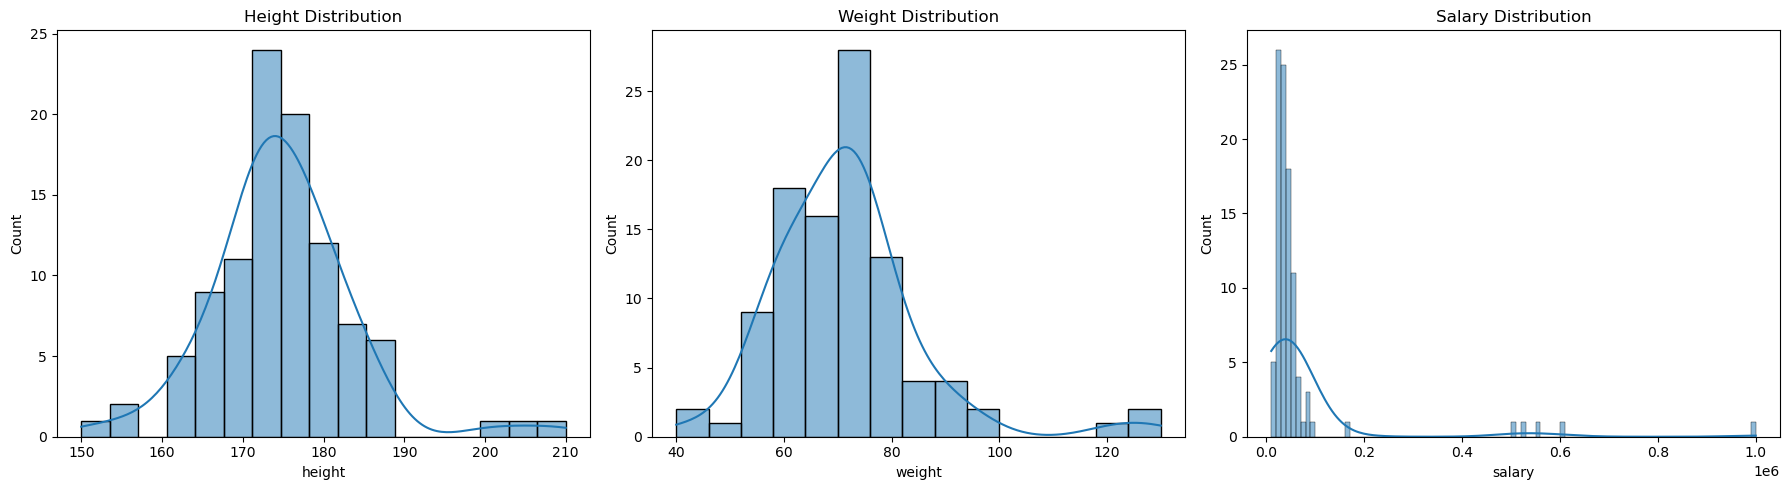

In [6]:
# Visualize distributions to identify potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['height'], kde=True)  #KDE is a smooth curve that estimates the probability distribution of your data.
plt.title('Height Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['weight'], kde=True)
plt.title('Weight Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['salary'], kde=True)
plt.title('Salary Distribution')

plt.tight_layout()
plt.show()

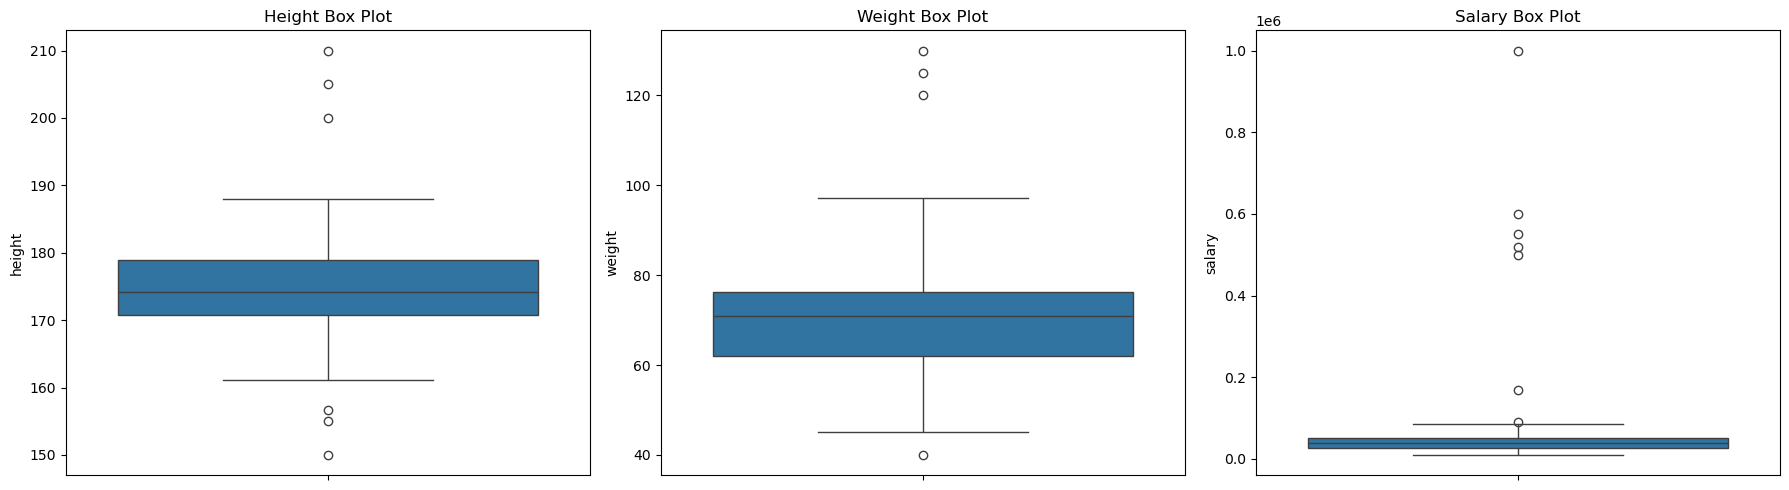

In [7]:
# Box plots to visualize potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['weight'])
plt.title('Weight Box Plot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['salary'])
plt.title('Salary Box Plot')

plt.tight_layout()
plt.show()

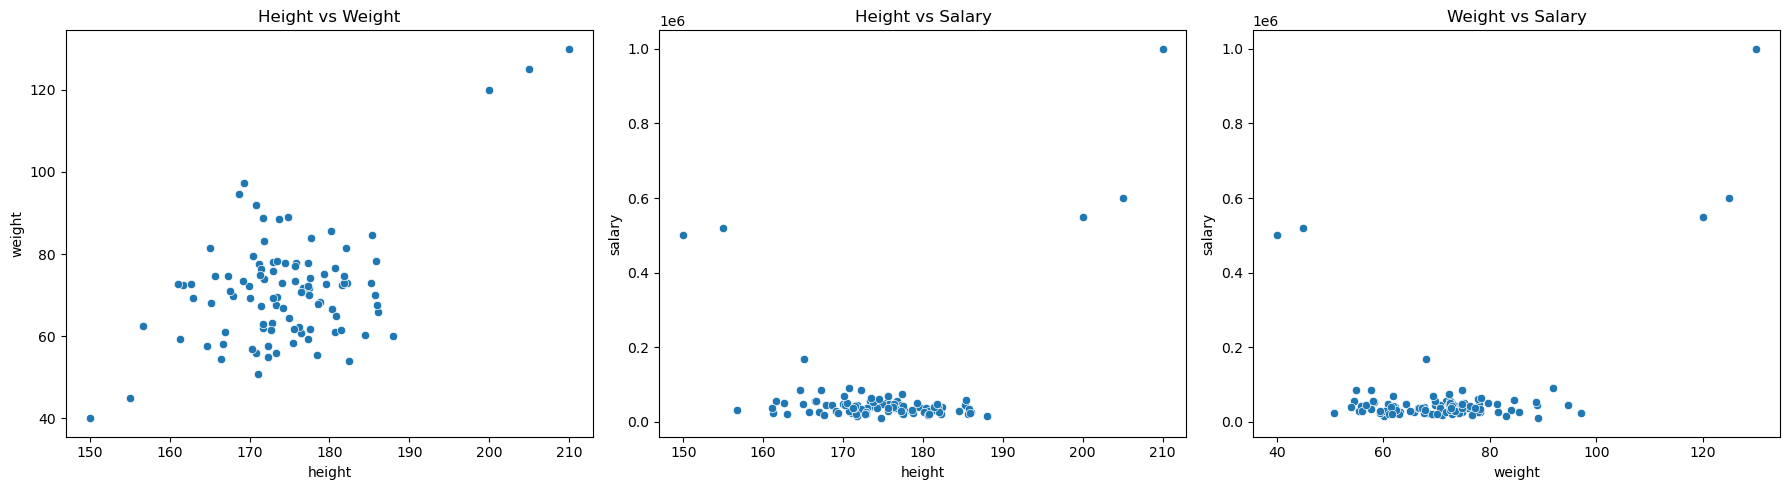

In [8]:
# Scatter plots to identify patterns and potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='height', y='weight', data=df)
plt.title('Height vs Weight')

plt.subplot(1, 3, 2)
sns.scatterplot(x='height', y='salary', data=df)
plt.title('Height vs Salary')

plt.subplot(1, 3, 3)
sns.scatterplot(x='weight', y='salary', data=df)
plt.title('Weight vs Salary')

plt.tight_layout()
plt.show()

In [9]:
# Define function for Z-score outlier detection
# This function identifies values that are unusually far from the mean (more than 3 standard deviations away) and 
# returns their positions in the dataset.
def detect_outliers_zscore(data, threshold=3):
    """
    Detect outliers using Z-score method
    Returns indices of outliers
    """ 
    z_scores = np.abs(stats.zscore(data))
    # (stats.zscore(data) -> Calculates the Z-score of every value.
    return np.where(z_scores > threshold)[0]


In [10]:
# Apply Z-score outlier detection
height_outliers_z = detect_outliers_zscore(df['height'])
weight_outliers_z = detect_outliers_zscore(df['weight'])
salary_outliers_z = detect_outliers_zscore(df['salary'])

print(f"Height outliers (Z-score): {len(height_outliers_z)} found at indices {height_outliers_z}")
print(f"Weight outliers (Z-score): {len(weight_outliers_z)} found at indices {weight_outliers_z}")
print(f"Salary outliers (Z-score): {len(salary_outliers_z)} found at indices {salary_outliers_z}")


Height outliers (Z-score): 2 found at indices [98 99]
Weight outliers (Z-score): 3 found at indices [97 98 99]
Salary outliers (Z-score): 5 found at indices [95 96 97 98 99]


In [11]:
# Define function for IQR outlier detection
def detect_outliers_iqr(data, factor=1.5):  # the standard multiplier used for outlier detection.
    """
    Detect outliers using IQR method
    Returns indices of outliers
    """
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1   # Calculates the spread of the middle 50% of the data.
    lower_bound = q1 - (factor * iqr)  #Calculates the minimum acceptable value before a point is considered an outlier.
    upper_bound = q3 + (factor * iqr)  #Calculates the maximum acceptable value before a point is considered an outlier.
    return np.where((data < lower_bound) | (data > upper_bound))[0]


In [12]:
# Apply IQR outlier detection
height_outliers_iqr = detect_outliers_iqr(df['height'])
weight_outliers_iqr = detect_outliers_iqr(df['weight'])
salary_outliers_iqr = detect_outliers_iqr(df['salary'])

print(f"Height outliers (IQR): {len(height_outliers_iqr)} found at indices {height_outliers_iqr}")
print(f"Weight outliers (IQR): {len(weight_outliers_iqr)} found at indices {weight_outliers_iqr}")
print(f"Salary outliers (IQR): {len(salary_outliers_iqr)} found at indices {salary_outliers_iqr}")


Height outliers (IQR): 6 found at indices [74 95 96 97 98 99]
Weight outliers (IQR): 4 found at indices [95 97 98 99]
Salary outliers (IQR): 7 found at indices [19 30 95 96 97 98 99]


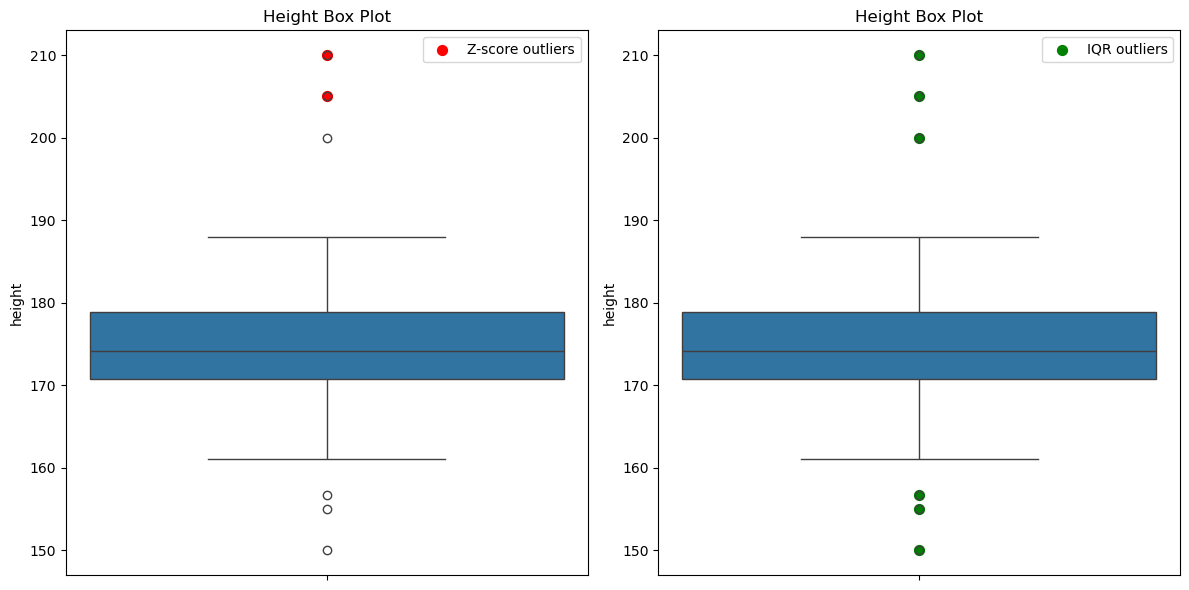

In [13]:
# Visualize the detected outliers for height using box plot with highlighted outliers
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_z), df['height'].iloc[height_outliers_z],
            color='red', s=50, label='Z-score outliers')

# It extracts the outlier values, places them at the same x-coordinate, and visually highlights them as red dots so 
# that you can easily identify which data points are considered outliers.
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_iqr), df['height'].iloc[height_outliers_iqr],
            color='green', s=50, label='IQR outliers')
plt.legend()

plt.tight_layout()
plt.show()


In [14]:
# Examining the impact of outliers on statistical measures
print("With outliers:")
# :.2f -> Show only 2 digits after the decimal point.
print(f"Height mean: {df['height'].mean():.2f}, std: {df['height'].std():.2f}")
print(f"Weight mean: {df['weight'].mean():.2f}, std: {df['weight'].std():.2f}")
print(f"Salary mean: {df['salary'].mean():.2f}, std: {df['salary'].std():.2f}")


With outliers:
Height mean: 174.80, std: 8.82
Weight mean: 71.40, std: 13.93
Salary mean: 70575.82, std: 138019.02


In [15]:
# Create copies without outliers (using IQR method)
df_no_outliers = df.copy()
all_outliers = list(set(height_outliers_iqr) | set(weight_outliers_iqr) | set(salary_outliers_iqr))
df_no_outliers = df_no_outliers.drop(all_outliers).reset_index(drop=True)

# "|" means "Union operator" (combine everything and remove duplicates).

print("\nWithout outliers:")
print(f"Height mean: {df_no_outliers['height'].mean():.2f}, std: {df_no_outliers['height'].std():.2f}")
print(f"Weight mean: {df_no_outliers['weight'].mean():.2f}, std: {df_no_outliers['weight'].std():.2f}")
print(f"Salary mean: {df_no_outliers['salary'].mean():.2f}, std: {df_no_outliers['salary'].std():.2f}")



Without outliers:
Height mean: 174.65, std: 6.18
Weight mean: 70.19, std: 9.50
Salary mean: 39059.91, std: 15713.95


In [16]:
# Handling outliers using different approaches
# 1. Removal (already done above)
# 2. Capping (Winsorization)
# Instead of deleting the outliers, we keep them in the dataset but replace extremely large or extremely small 
# values with reasonable limits.This technique is called: Winsorization (or Capping).

def winsorize(data, limits=(0.05, 0.05)):  # Sets the lower and upper percentage limits for capping.
    """Apply winsorization to limit extreme values"""
    lower_limit = np.percentile(data, limits[0] * 100)
    upper_limit = np.percentile(data, 100 - limits[1] * 100)
    return np.clip(data, lower_limit, upper_limit)

df_winsorized = df.copy()
df_winsorized['height'] = winsorize(df['height'])
df_winsorized['weight'] = winsorize(df['weight'])
df_winsorized['salary'] = winsorize(df['salary'])


In [17]:
# 3. Log transformation (especially useful for skewed data like salary)
df_log = df.copy()
df_log['salary'] = np.log(df['salary'])
# Compresses large salary values to reduce skewness and make the data more normally distributed.

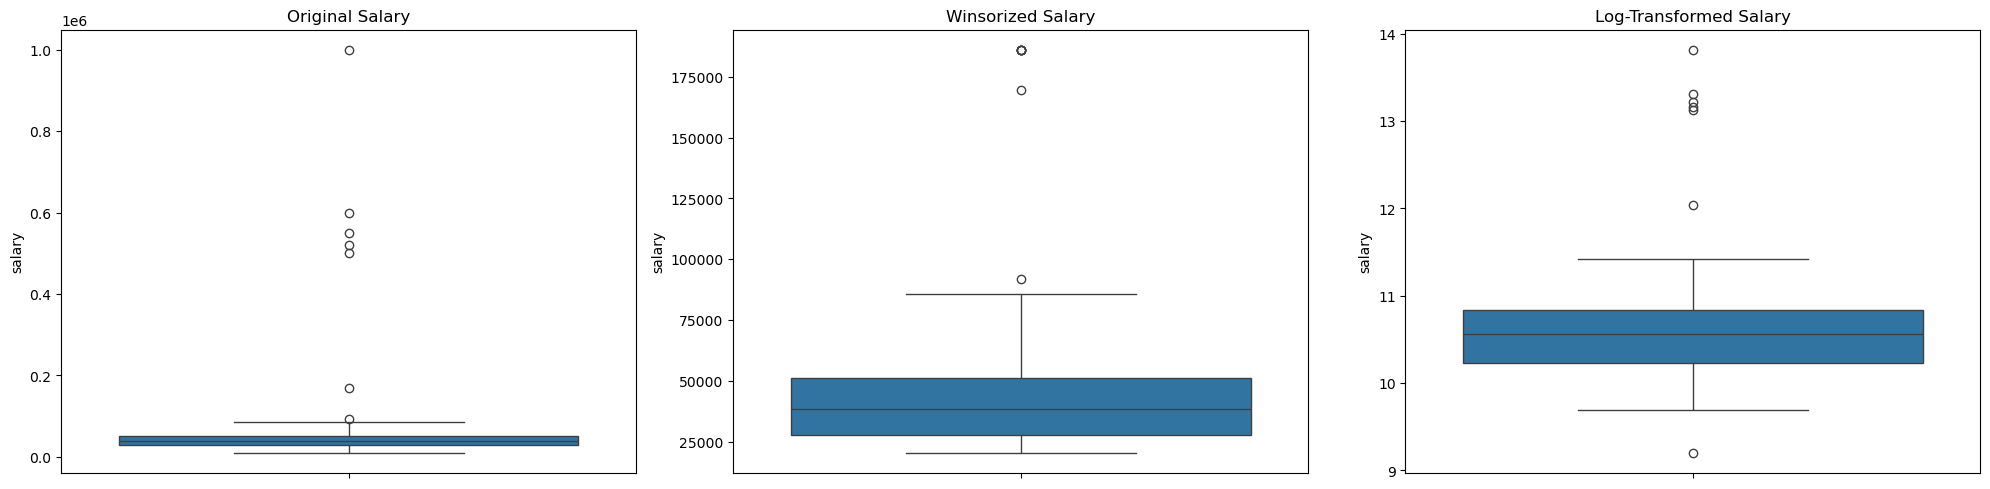

In [18]:
# Compare the distributions before and after transformation
plt.figure(figsize=(20, 5))

# Original distributions
plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

# After winsorization
plt.subplot(1, 3, 2)
sns.boxplot(y=df_winsorized['salary'])
plt.title('Winsorized Salary')

# After log transformation
plt.subplot(1, 3, 3)
sns.boxplot(y=df_log['salary'])
plt.title('Log-Transformed Salary')

plt.tight_layout()
plt.show()

In [19]:
# Feature associations and correlation analysis
# Calculate correlation matrix
corr_matrix = df.corr()


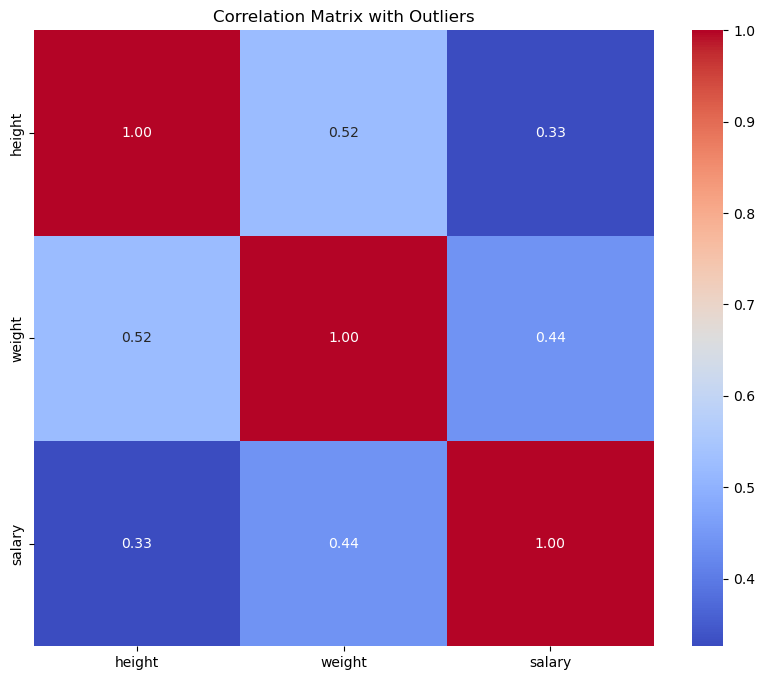

In [20]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix with Outliers')
plt.show()


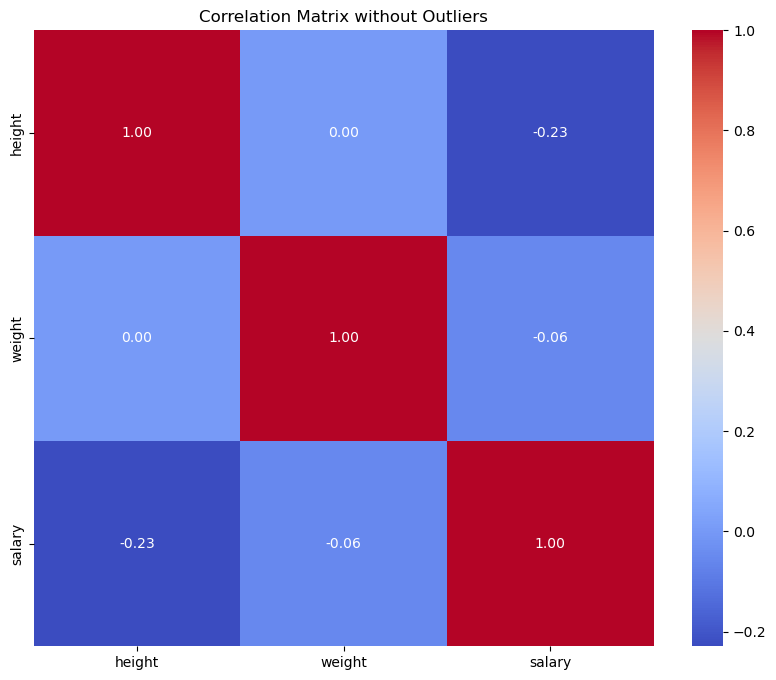

In [21]:
# Compare with correlation after removing outliers
corr_matrix_no_outliers = df_no_outliers.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_no_outliers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix without Outliers')
plt.show()


In [22]:
# Create function to profile features and detect potential issues
def profile_feature(data, feature_name):
    """Create a basic profile of a numeric feature"""
    feature = data[feature_name]

    # Basic statistics
    stats_dict = {
        'Count': len(feature),
        'Mean': feature.mean(),
        'Median': feature.median(),
        'Std Dev': feature.std(),
        'Min': feature.min(),
        'Max': feature.max(),
        'Range': feature.max() - feature.min(),
        'IQR': np.percentile(feature, 75) - np.percentile(feature, 25),
        'Skewness': stats.skew(feature),
        'Kurtosis': stats.kurtosis(feature),
        'Missing Values': feature.isna().sum(),
        'Missing %': feature.isna().mean() * 100
    }

    # Z-score outliers
    z_outliers = detect_outliers_zscore(feature)
    stats_dict['Z-score Outliers'] = len(z_outliers)
    stats_dict['Z-score Outlier %'] = len(z_outliers) / len(feature) * 100

    # IQR outliers
    iqr_outliers = detect_outliers_iqr(feature)
    stats_dict['IQR Outliers'] = len(iqr_outliers)
    stats_dict['IQR Outlier %'] = len(iqr_outliers) / len(feature) * 100

    return pd.Series(stats_dict, name=feature_name)


In [23]:
# Apply feature profiling to the dataset
profile_results = pd.DataFrame([
    profile_feature(df, 'height'),
    profile_feature(df, 'weight'),
    profile_feature(df, 'salary')
])

# Display the feature profiles
profile_results


,Count,Mean,Median,Std Dev,Min,Max,Range,IQR,Skewness,Kurtosis,Missing Values,Missing %,Z-score Outliers,Z-score Outlier %,IQR Outliers,IQR Outlier %
height,100.0,174.802581,174.111306,8.824677,150.000000,210.0,60.000000,8.206793,0.802248,3.330725,0.0,0.0,2.0,2.0,6.0,6.0
weight,100.0,71.397280,70.841072,13.932214,40.000000,130.0,90.000000,14.390494,1.587588,4.962706,0.0,0.0,3.0,3.0,4.0,4.0
salary,100.0,70575.816571,38441.915870,138019.017873,9931.760814,1000000.0,990068.239186,23348.615150,4.740303,23.787349,0.0,0.0,5.0,5.0,7.0,7.0


In [ ]:
# Fixed function for multivariate outlier detection
def detect_multivariate_outliers(data, method='mahalanobis', threshold=0.99):
    """
    Detect multivariate outliers using Mahalanobis distance
    Returns indices of outliers
    """
    if method == 'mahalanobis':
        # Calculate Mahalanobis distance
        # Measure multivariate abnormality
        x = data.values
        covariance_matrix = np.cov(x, rowvar=False)
        inv_covariance_matrix = np.linalg.inv(covariance_matrix)
        mean_vector = np.mean(x, axis=0)

        # Implement mahalanobis distance manually
        mahalanobis_dist = []
        for i in range(x.shape[0]):
            x_i = x[i, :]
            # Calculate mahalanobis distance: (x-μ)ᵀΣ⁻¹(x-μ)
            diff = x_i - mean_vector
            mahal = np.sqrt(diff.dot(inv_covariance_matrix).dot(diff.T))
            #Calculate how unusual an observation is when all features are considered together.
            mahalanobis_dist.append(mahal)

        # Convert to array
        mahalanobis_dist = np.array(mahalanobis_dist)

        # Find threshold using chi-squared distribution
        threshold_value = stats.chi2.ppf(threshold, df=x.shape[1])

        # Return indices of outliers
        return np.where(mahalanobis_dist > threshold_value)[0]
    else:
        raise ValueError("Only 'mahalanobis' method is currently supported")


In [ ]:
# Apply multivariate outlier detection
multivariate_outliers = detect_multivariate_outliers(df, threshold=0.95)
print(f"Multivariate outliers: {len(multivariate_outliers)} found at indices {multivariate_outliers}")


In [ ]:
# Visualize the multivariate outliers in a pair plot
plt.figure(figsize=(12, 10))
sns.pairplot(df, diag_kind='kde', plot_kws={"s": 20})
plt.suptitle('Pair Plot of Features', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Highlight the multivariate outliers in a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='height', y='weight', data=df, alpha=0.6)
sns.scatterplot(x='height', y='weight', data=df.iloc[multivariate_outliers],
                color='red', s=100, label='Multivariate Outliers')
plt.title('Height vs Weight with Multivariate Outliers Highlighted')
plt.legend()
plt.show()


In [ ]:
# 3D visualization of outliers
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Regular points
ax.scatter(df['height'], df['weight'], df['salary'], c='blue', s=40, alpha=0.6, label='Normal Points')
# Outliers
ax.scatter(df.iloc[multivariate_outliers]['height'], df.iloc[multivariate_outliers]['weight'],
           df.iloc[multivariate_outliers]['salary'], c='red', s=100, label='Outliers')

ax.set_xlabel('Height')
ax.set_ylabel('Weight')
ax.set_zlabel('Salary')
ax.set_title('3D Visualization of Multivariate Outliers')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Simple robust correlation calculation using Spearman instead of Pearson
robust_corr = df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(robust_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Robust Correlation Matrix (Spearman)')
plt.show()


In [ ]:
# Apply different scaling methods before and after outlier treatment
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [ ]:
# Original data
scaler_standard = StandardScaler()
df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)


In [ ]:
# Using robust scaler which is less influenced by outliers
scaler_robust = RobustScaler()
df_scaled_robust = pd.DataFrame(
    scaler_robust.fit_transform(df),
    columns=df.columns
)

In [ ]:
# Compare the scaled distributions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_scaled_standard['salary'])
plt.title('Standard Scaled Salary')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_scaled_robust['salary'])
plt.title('Robust Scaled Salary')

plt.tight_layout()
plt.show()


In [ ]:
# Demonstrate impact of outliers on linear regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [ ]:
# Create dataset with outlier
x = np.array(range(20)).reshape(-1, 1)
y = 2*x.ravel() + 5 + np.random.normal(0, 1, 20)
y[19] = 80  # add outlier

plt.figure(figsize=(12, 6))


In [ ]:
# Plot with outlier
plt.subplot(1, 2, 1)
plt.scatter(x, y)
model = LinearRegression().fit(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'With Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')


In [ ]:
# Plot without outlier
plt.subplot(1, 2, 2)
plt.scatter(x[:-1], y[:-1])
model = LinearRegression().fit(x[:-1], y[:-1])
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'Without Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

plt.tight_layout()
plt.show()

# Interactive Coding Exercise: Advanced Outlier Detection & Analysis


In [ ]:
# ----------------------------------------------------------------
# In this exercise, you'll work with a real-world dataset to:
# 1. Apply outlier detection techniques
# 2. Compare methods and their impact
# 3. Implement a custom outlier detection workflow

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the California housing dataset instead of Boston
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Create a DataFrame with all features plus the target
df = X.copy()
df['MedHouseVal'] = y  # The target is median house value

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFeature names:", list(X.columns))
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


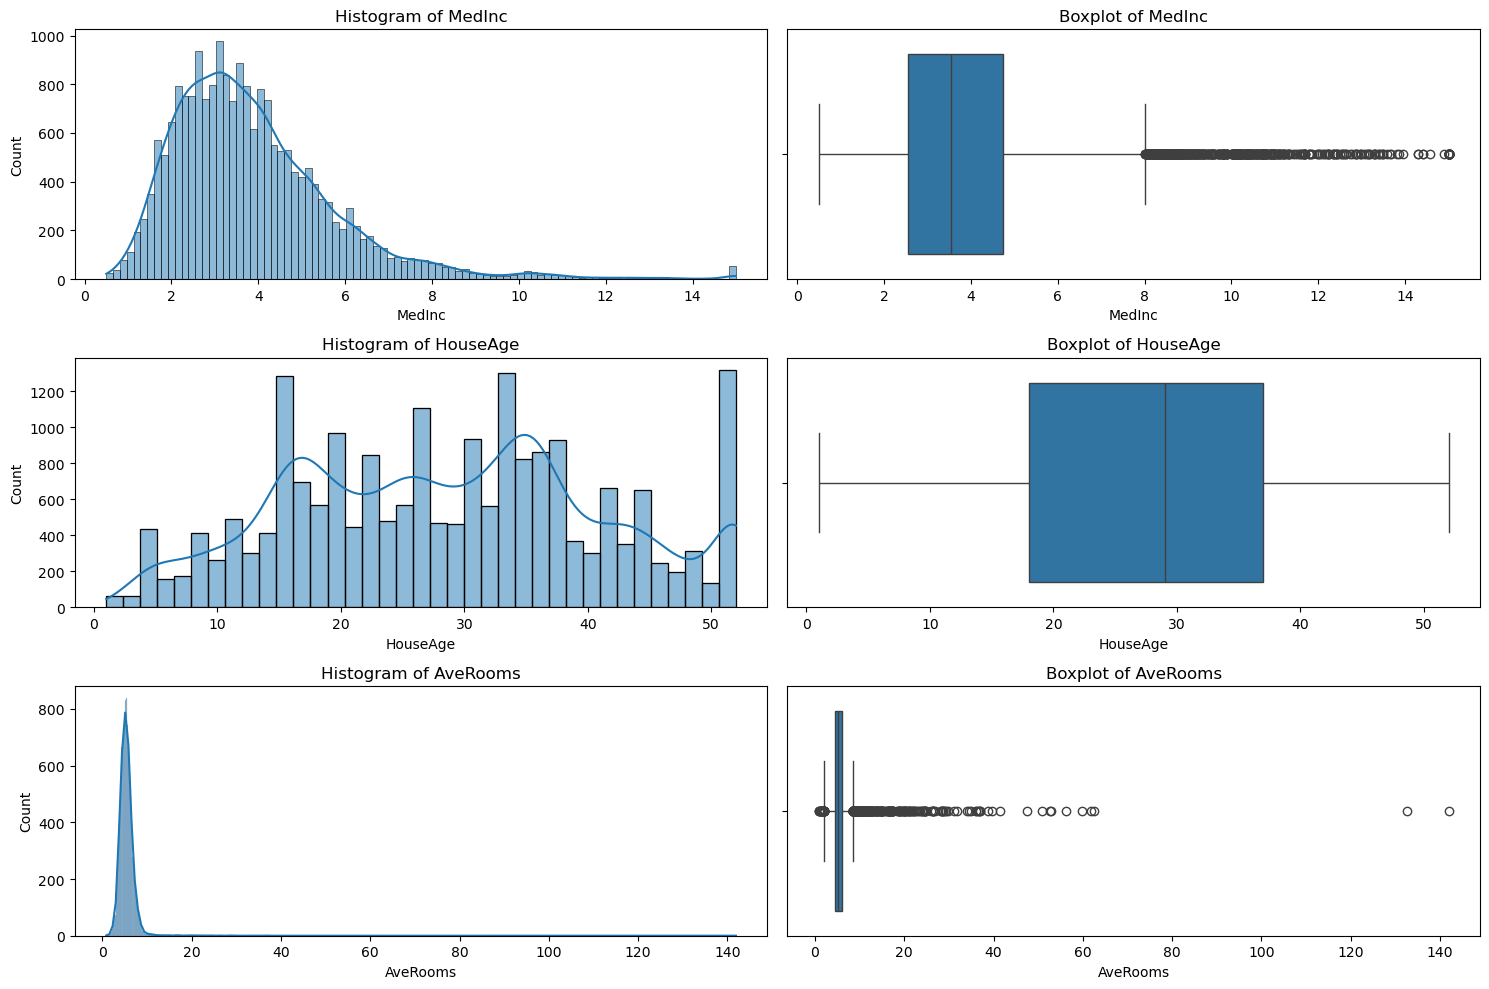

In [ ]:
# EXERCISE 1: Exploratory Data Analysis for Outlier Detection
# -----------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Select 3 numerical features
features = ['MedInc', 'HouseAge', 'AveRooms']

# Create subplots
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features):

    # Histogram
    plt.subplot(3, 2, 2*i + 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Histogram of {feature}')

    # Boxplot
    plt.subplot(3, 2, 2*i + 2)
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')

plt.tight_layout()
plt.show()

In [5]:
# EXERCISE 2: Implement Multiple Outlier Detection Methods
# -------------------------------------------------------
from scipy import stats
import numpy as np

# Z-Score Method

z_scores = np.abs(stats.zscore(df['MedHouseVal']))

# Threshold = 3
z_outliers = np.where(z_scores > 3)[0]

print("Number of Z-score outliers:", len(z_outliers))


# IQR Method

Q1 = df['MedHouseVal'].quantile(0.25)
Q3 = df['MedHouseVal'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

iqr_outliers = np.where(
    (df['MedHouseVal'] < lower_bound) |
    (df['MedHouseVal'] > upper_bound)
)[0]

print("Number of IQR outliers:", len(iqr_outliers))

Number of Z-score outliers: 0
Number of IQR outliers: 1071


In [7]:
# EXERCISE 3: Advanced Outlier Detection - Isolation Forest
# --------------------------------------------------------
from sklearn.ensemble import IsolationForest

# Create the Isolation Forest model
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Fit the model and predict outliers
outlier_predictions = iso_forest.fit_predict(df)

# Print the predictions
print(outlier_predictions)

# Boolean mask (True = Outlier)
outlier_mask = outlier_predictions == -1

print(outlier_mask)

[1 1 1 ... 1 1 1]
[False False False ... False False False]


In [ ]:
# EXERCISE 4: Compare the Impact of Outliers on Linear Regression
# --------------------------------------------------------------

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Features and target
df = df.rename(columns={'MedHouseVal': 'PRICE'})
df.rename(columns={'MedHouseVal': 'PRICE'}, inplace=True)
X = df[['MedInc']]
y = df['PRICE']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
lr_all = LinearRegression()
lr_all.fit(X_train, y_train)

# Predictions
y_pred_all = lr_all.predict(X_test)

# R² Score
r2_all = r2_score(y_test, y_pred_all)

print("R² Score (All Data):", r2_all)
print("Coefficient:", lr_all.coef_[0])


R² Score (All Data): 0.45885918903846656
Coefficient: 0.4193384939381274


In [11]:
from scipy import stats
import numpy as np

# Calculate Z-scores
z_scores = np.abs(stats.zscore(df['PRICE']))

# Keep only non-outliers
df_z = df[z_scores <= 3]

# Features and target
X_z = df_z[['MedInc']]
y_z = df_z['PRICE']

# Split data
X_train_z, X_test_z, y_train_z, y_test_z = train_test_split(
    X_z, y_z, test_size=0.2, random_state=42
)

# Train model
lr_z = LinearRegression()
lr_z.fit(X_train_z, y_train_z)

# Predictions
y_pred_z = lr_z.predict(X_test_z)

# R² Score
r2_z = r2_score(y_test_z, y_pred_z)

print("\nR² Score (Without Z-score Outliers):", r2_z)
print("Coefficient:", lr_z.coef_[0])


R² Score (Without Z-score Outliers): 0.45885918903846656
Coefficient: 0.4193384939381274


In [12]:
from sklearn.ensemble import IsolationForest

# Detect outliers
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

predictions = iso.fit_predict(df[['MedInc', 'PRICE']])

# Keep only normal observations
df_iso = df[predictions == 1]

# Features and target
X_iso = df_iso[['MedInc']]
y_iso = df_iso['PRICE']

# Split data
X_train_iso, X_test_iso, y_train_iso, y_test_iso = train_test_split(
    X_iso,
    y_iso,
    test_size=0.2,
    random_state=42
)

# Train model
lr_iso = LinearRegression()
lr_iso.fit(X_train_iso, y_train_iso)

# Predictions
y_pred_iso = lr_iso.predict(X_test_iso)

# R² Score
r2_iso = r2_score(y_test_iso, y_pred_iso)

print("\nR² Score (Without Isolation Forest Outliers):", r2_iso)
print("Coefficient:", lr_iso.coef_[0])


R² Score (Without Isolation Forest Outliers): 0.4492059093381854
Coefficient: 0.47125105797725353


In [13]:
print("\n----- Comparison -----")

print("All Data")
print("R² Score =", r2_all)
print("Coefficient =", lr_all.coef_[0])

print("\nZ-score Method")
print("R² Score =", r2_z)
print("Coefficient =", lr_z.coef_[0])

print("\nIsolation Forest Method")
print("R² Score =", r2_iso)
print("Coefficient =", lr_iso.coef_[0])


----- Comparison -----
All Data
R² Score = 0.45885918903846656
Coefficient = 0.4193384939381274

Z-score Method
R² Score = 0.45885918903846656
Coefficient = 0.4193384939381274

Isolation Forest Method
R² Score = 0.4492059093381854
Coefficient = 0.47125105797725353


In [16]:
# EXERCISE 5: Create Your Own Outlier Detection Workflow
# Custom function
def custom_outlier_detection(df, column_name):

    # Method 1: Z-score

    z_scores = np.abs(stats.zscore(df[column_name]))
    z_outliers = np.where(z_scores > 3)[0]

    # Method 2: IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    iqr_outliers = np.where(
        (df[column_name] < lower_bound) |
        (df[column_name] > upper_bound)
    )[0]

    # Consensus Outliers

    consensus_outliers = list(
        set(z_outliers).intersection(set(iqr_outliers))
    )

    # Visualization

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[column_name])

    plt.title(f"Outliers in {column_name}")

    plt.show()

    # Results
    print("Z-score Outliers:", len(z_outliers))
    print("IQR Outliers:", len(iqr_outliers))
    print("Consensus Outliers:", len(consensus_outliers))

    return consensus_outliers

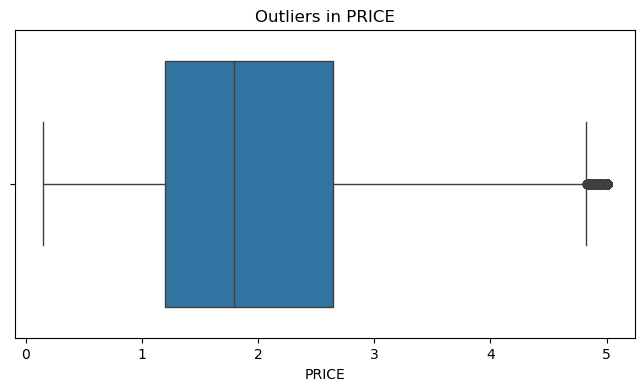

Z-score Outliers: 0
IQR Outliers: 1071
Consensus Outliers: 0
[]


In [17]:
outliers = custom_outlier_detection(
    df,
    'PRICE'
)

print(outliers)

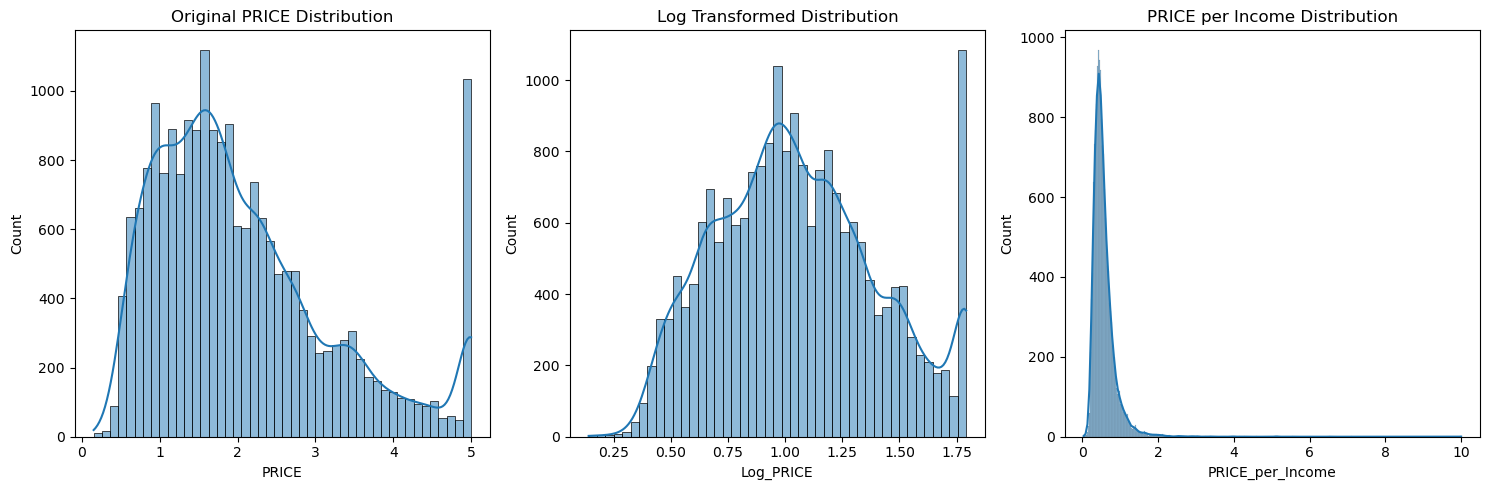


PRICE Bin Counts:

PRICE_Bin
Low          5162
Medium       5161
Very High    5160
High         5157
Name: count, dtype: int64

New Features Created:

   PRICE  Log_PRICE  PRICE_Bin  PRICE_per_Income
0  4.526   1.709464  Very High          0.543651
1  3.585   1.522790  Very High          0.431855
2  3.521   1.508733  Very High          0.485160
3  3.413   1.484555  Very High          0.604809
4  3.422   1.486592  Very High          0.889709


In [19]:
# EXERCISE 6: Robust Feature Engineering with Outliers

# 1. LOG TRANSFORMATION

# Create a log-transformed feature
df['Log_PRICE'] = np.log(df['PRICE'] + 1)

# (+1 is added to avoid errors if any value is 0)

# 2. BINNING / DISCRETIZATION

# Divide PRICE into 4 categories
df['PRICE_Bin'] = pd.qcut(
    df['PRICE'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

# 3. RATIO / INTERACTION FEATURE

# Create a ratio feature
# House price per median income

df['PRICE_per_Income'] = (
    df['PRICE'] / df['MedInc']
)

# 4. VISUALIZE THE DISTRIBUTIONS

plt.figure(figsize=(15, 5))

# Original Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['PRICE'], kde=True)
plt.title("Original PRICE Distribution")


# Log Transformed Distribution
plt.subplot(1, 3, 2)
sns.histplot(df['Log_PRICE'], kde=True)
plt.title("Log Transformed Distribution")


# Ratio Feature Distribution
plt.subplot(1, 3, 3)
sns.histplot(df['PRICE_per_Income'], kde=True)
plt.title("PRICE per Income Distribution")


plt.tight_layout()
plt.show()

# 5. DISPLAY THE BINNING RESULT

print("\nPRICE Bin Counts:\n")
print(df['PRICE_Bin'].value_counts())

# 6. DISPLAY THE NEW FEATURES

print("\nNew Features Created:\n")

print(df[
    [
        'PRICE',
        'Log_PRICE',
        'PRICE_Bin',
        'PRICE_per_Income'
    ]
].head())

Number of Multivariate Outliers:
23


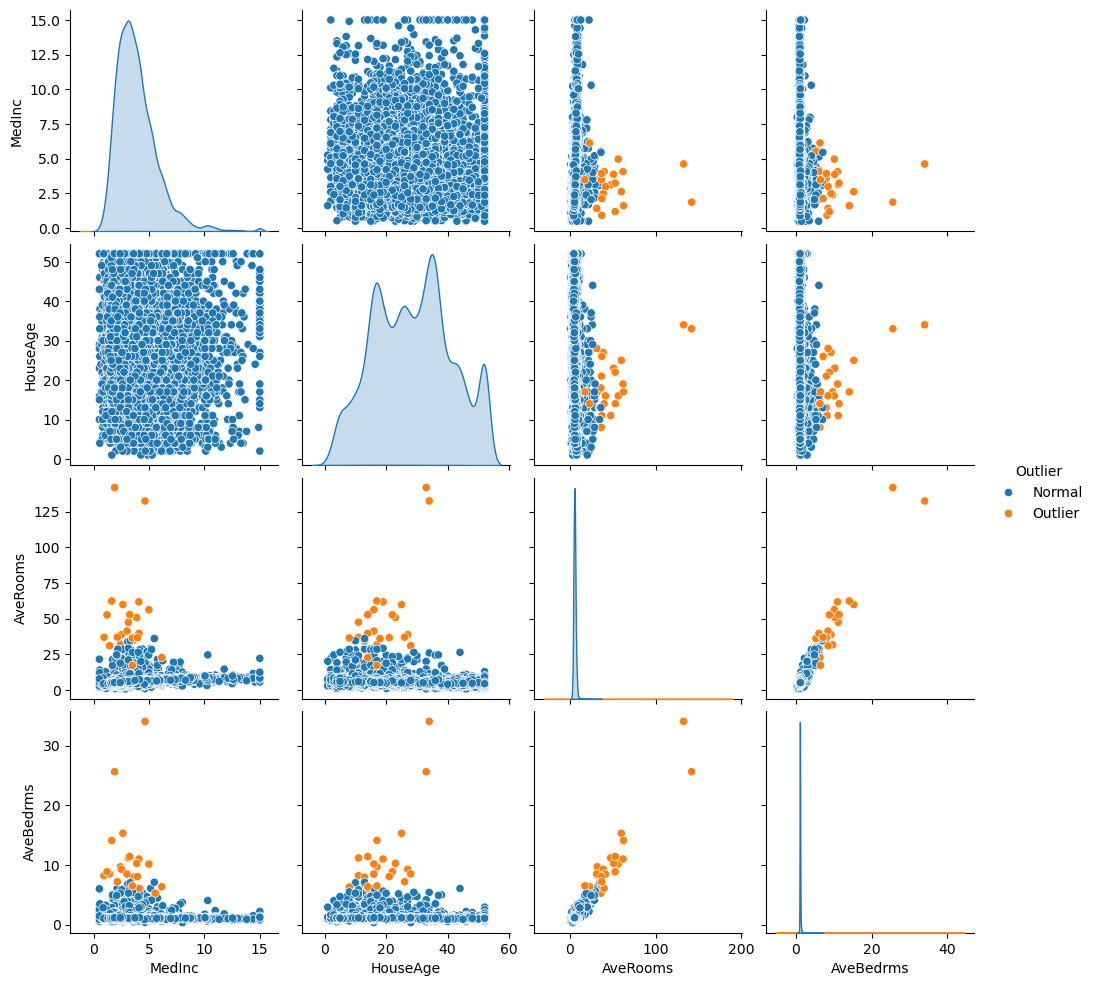

In [ ]:
# EXERCISE 7: BONUS CHALLENGE - Multivariate Outlier Detection
# ------------------------------------------------------------

# Select numerical features

features = [
    'MedInc',
    'HouseAge',
    'AveRooms',
    'AveBedrms'
]

X = df[features]

# Calculate Mean Vector. Finds the center of the multivariate dataset.

mean_vector = np.mean(X, axis=0)

# Calculate Covariance Matrix. Captures the spread and relationships among the features.

cov_matrix = np.cov(X, rowvar=False)

# Calculate Inverse Covariance Matrix. Adjusts the distance calculation based on variance and correlations.

inv_cov_matrix = np.linalg.inv(cov_matrix)

# Calculate Mahalanobis Distance. Measures how unusual a point is relative to the entire dataset.

mahal_distances = []

for i in range(X.shape[0]):

    x = X.iloc[i].values

    diff = x - mean_vector

    mahal_distance = np.sqrt(
        diff.dot(inv_cov_matrix).dot(diff.T)
    )

    mahal_distances.append(mahal_distance)


# Convert into NumPy Array
mahal_distances = np.array(mahal_distances)

# We calculate the Chi-Square threshold because Mahalanobis Distance by itself only gives us a number. 
# It does not tell us whether that number is "normal" or "abnormal."
# Calculate Chi-Square Threshold

threshold = stats.chi2.ppf(
    0.99,  #means we are keeping 99% of the normal data.
    df=len(features)
)

# Detect Outliers

outlier_indices = np.where(
    mahal_distances > threshold
)[0]

# Display Results

print("Number of Multivariate Outliers:")
print(len(outlier_indices))

# Create an Outlier Column
df['Outlier'] = "Normal"

df.loc[
    outlier_indices,
    'Outlier'
] = "Outlier"

# Visualize Scatter Plot Matrix

sns.pairplot(
    df,
    vars=features,
    hue='Outlier'
)

plt.show()